# **House Price Prediction Analysis**

### `About Dataset`
This dataset contains property listings from various cities across Bangladesh, specifically including Dhaka, Chattogram, Cumilla, Narayanganj City, and Gazipur, with prices listed in Bangladeshi Taka (৳). The dataset provides valuable insights into various features of the properties, including the number of bedrooms, bathrooms, floor number, floor area in square feet, and their respective prices. The data has been collected from a real estate website, offering a comprehensive view of the housing market across these key cities in Bangladesh.

### `Feature Description`
Title: The title or description of the property listing.

Bedrooms: The number of bedrooms in the property.

Bathrooms: The number of bathrooms in the property.

Floor_no: The floor number on which the property is located.

Occupancy_status: Indicates whether the property is vacant or occupied.

Floor_area: The total floor area of the property in square feet.

City: The city where the property is located. This dataset includes listings from Dhaka, Chattogram, Cumilla, Narayanganj City, and Gazipur.

Price_in_taka: The listing price of the property in Bangladeshi Taka (৳).

Location: The specific location or address within the city.

# **1. Import Libraries**

In [42]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#hide warnings
import warnings
warnings.filterwarnings('ignore')

# **2. Load and Explore Data**

## 2.1. **Load Dataset**

In [43]:
df = pd.read_csv('/kaggle/input/house-price-bangladesh/house_price_bd.csv')
df.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,"৳47,500,000","Road No 25, Banani"


## **2.2 Explore the Data**

In [44]:
print('This dataset has',df.shape[0],'rows and',df.shape[1],'columns.')

This dataset has 3865 rows and 9 columns.


In [45]:
df.columns

Index(['Title', 'Bedrooms', 'Bathrooms', 'Floor_no', 'Occupancy_status',
       'Floor_area', 'City', 'Price_in_taka', 'Location'],
      dtype='object')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3865 entries, 0 to 3864
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             3865 non-null   object 
 1   Bedrooms          2864 non-null   float64
 2   Bathrooms         2864 non-null   float64
 3   Floor_no          3181 non-null   object 
 4   Occupancy_status  3766 non-null   object 
 5   Floor_area        3766 non-null   float64
 6   City              3865 non-null   object 
 7   Price_in_taka     3865 non-null   object 
 8   Location          3859 non-null   object 
dtypes: float64(3), object(6)
memory usage: 271.9+ KB


## **2.3. Typecasting**

we observe that Floor_no and Price_in_taka are object data type and need to be convertted into float.

`Floor_no column`

In [47]:
df['Floor_no'].value_counts()

Floor_no
1                       532
4                       418
5                       402
2                       397
3                       366
6                       316
7                       252
8                       228
9                       167
10                       30
11                       26
12                       19
13                        8
Merin City - Purbach      6
14                        2
8th                       2
4th to 8th Backside       2
1st                       1
A1,A2,A3,A4,A5,A6,A7      1
0+7                       1
1F                        1
18                        1
5th                       1
17                        1
G+7                       1
Name: count, dtype: int64

In [48]:
def clean_floor_no(floor):
    # Convert to string if it's not already
    if not isinstance(floor, str):
        return None
    
    # Convert to lower case
    floor = floor.lower()
    
    # If it's numeric, return as is
    if floor.isdigit():
        return floor
    
    # If it ends with 'st', 'nd', 'rd', or 'th', remove the suffix
    if floor.endswith('st') or floor.endswith('nd') or floor.endswith('rd') or floor.endswith('th'):
        return floor.rstrip('stndrth')
    
    # If it doesn't meet the above criteria, return None (indicating removal)
    return None

df['Floor_no'] = df['Floor_no'].apply(clean_floor_no)
df = df.dropna(subset=['Floor_no'])
df['Floor_no'] = pd.to_numeric(df['Floor_no'],errors='coerce')

df['Floor_no'].dtype

dtype('int64')

`Price_in_taka column`

In [49]:
df['Price_in_taka'].value_counts()

Price_in_taka
৳6,000,000      92
৳5,000,000      82
৳6,500,000      82
৳8,000,000      74
৳5,500,000      69
                ..
৳52,000,000      1
৳101,500,000     1
৳14,662,500      1
৳23,110,000      1
৳4,112,000       1
Name: count, Length: 628, dtype: int64

In [50]:
# Function to clean the 'Price_in_taka' column
def clean_price(price):
    # Remove the currency symbol (assuming it's always '৳')
    price = price.replace('৳', '')
    
    # Remove commas
    price = price.replace(',', '')
    
    # Convert to numeric (int or float)
    price = pd.to_numeric(price, errors='coerce')
    
    return price

# Apply the cleaning function to the 'Price_in_taka' column
df['Price_in_taka'] = df['Price_in_taka'].apply(clean_price)
df['Price_in_taka'].dtype

dtype('int64')

## **2.4. Descriptive Statistics**

In [51]:
df.describe()

,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka
count,2826.000000,2826.000000,3169.000000,3169.000000,3.169000e+03
mean,2.995046,2.946214,4.448091,1476.314295,1.166222e+07
std,1.071915,0.799519,2.676103,1438.391520,2.270795e+07
min,1.000000,1.000000,1.000000,84.000000,1.050000e+06
25%,3.000000,3.000000,2.000000,1080.000000,5.000000e+06
50%,3.000000,3.000000,4.000000,1320.000000,7.100000e+06
75%,3.000000,3.000000,6.000000,1580.000000,1.102820e+07
max,27.000000,10.000000,18.000000,24000.000000,3.632000e+08


### **Correlation Matrix**
The correlation matrix is a square matrix that contains the correlation coefficients between each pair of variables.

<Axes: >

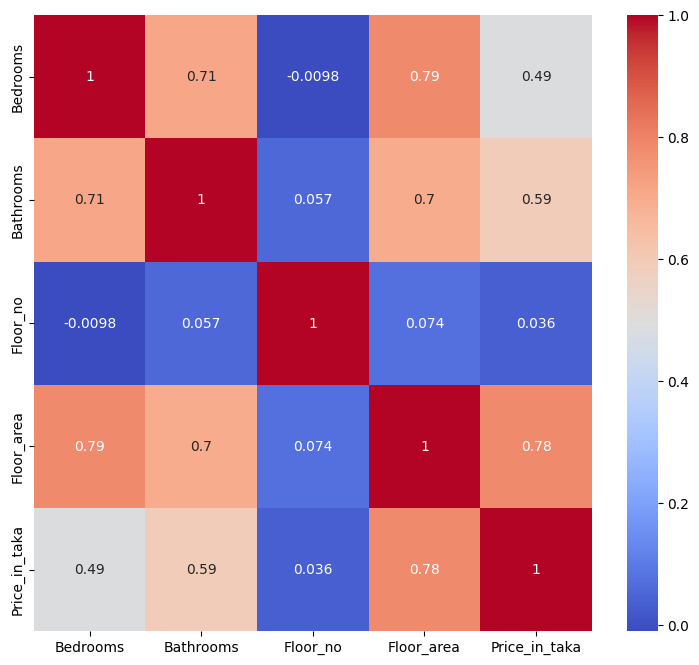

In [52]:
df_corr=df.select_dtypes(include='number').corr()
plt.figure(figsize=(9, 8))
sns.heatmap(df_corr,cmap ='coolwarm', annot=True)

<Figure size 500x500 with 0 Axes>

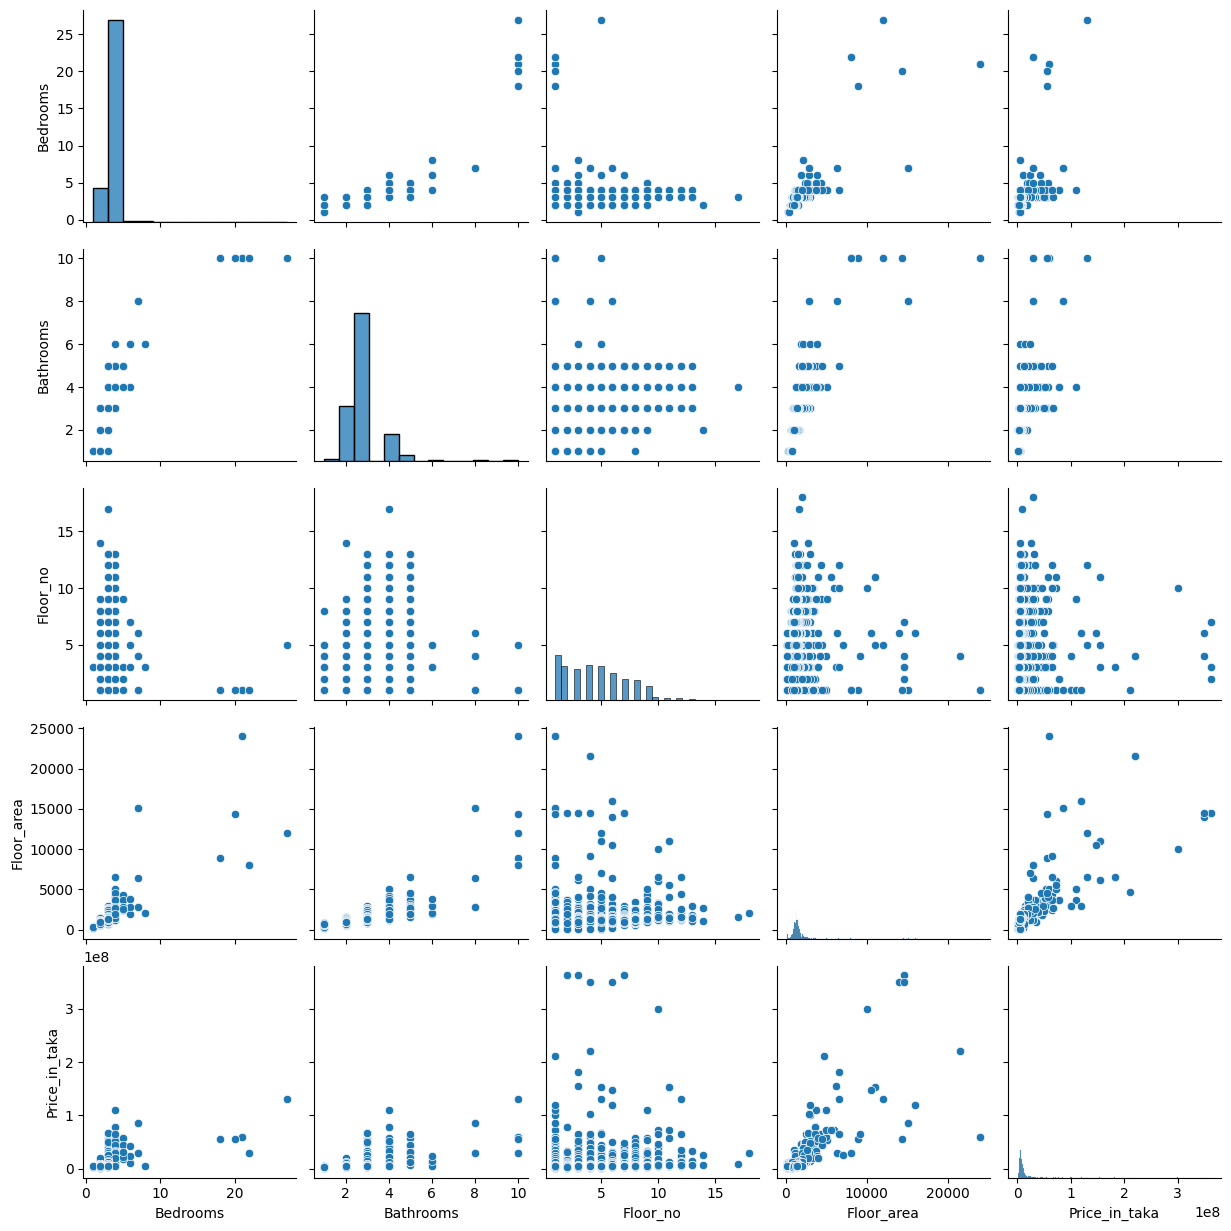

In [53]:
plt.figure(figsize=(5,5))
sns.pairplot(df)

## **`Observations`**
- The average household has 3 bedrooms, wiht the number of bedrooms ranging from 1 to 27.
- On average, there are 3 bathrooms per household, with the number of bathrooms varying between 1 and 10.
- Properties are typically located on the 4th floor, with floors ranging from 1st to 18th.
- The floor area of the properties averages around 1,476 square feet, with the smallest being 84 square feet - and the largest being 24,000 square feet.
- The average price of a property is approximately 11.66 million Taka, with prices ranging from 1.05 million Taka to 363.2 million Taka.
- There are missing values and outliers in the dataset that should be addressed.

`Correlation Matrix`
- Price has a strong positive correlation with floor area (0.78), meaning larger properties tend to be more expensive.
- There is a moderate positive correlation between the number of bathrooms and price (0.59), indicating that properties with more bathrooms tend to be higher-priced.
- The number of bedrooms is moderately correlated with price (0.49), showing that properties with more bedrooms are generally more expensive.

# **3. Data Cleaning**

## **3.1. Missing Values**

In [54]:
print('Percentage of missing values')
df.isnull().sum() / len(df) * 100

Percentage of missing values


Title                0.000000
Bedrooms            10.823604
Bathrooms           10.823604
Floor_no             0.000000
Occupancy_status     0.000000
Floor_area           0.000000
City                 0.000000
Price_in_taka        0.000000
Location             0.031556
dtype: float64

In [55]:
# Write a function to impute missing values of a column base on another column
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
def impute_missing_values(df, target_col, predictor_col, n_estimators=100, random_state=42):
    
    # Split the data into two sets: one with missing values and one without
    df_missing = df[df[target_col].isna()]
    df_non_missing = df.dropna(subset=[target_col])
    
    # Prepare the features (predictor) and target
    X = df_non_missing[[predictor_col]]
    y = df_non_missing[target_col]
    
    # Train a Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
    rf.fit(X, y)
    
    # Predict the missing values
    imputed_values = rf.predict(df_missing[[predictor_col]])
    
    # Fill in the missing values in the original DataFrame
    df.loc[df[target_col].isna(), target_col] = imputed_values
    
    return df

In [56]:
df = impute_missing_values(df,'Bedrooms','Floor_area')
df = impute_missing_values(df,'Bathrooms','Floor_area')

## **3.2. Duplicates**

In [57]:
df.duplicated().sum()

824

In [58]:
df.drop_duplicates(inplace=True)

## **3.3. Outliers**

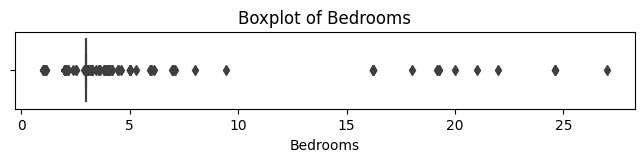

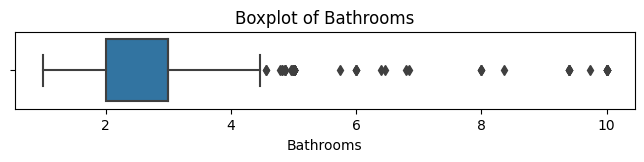

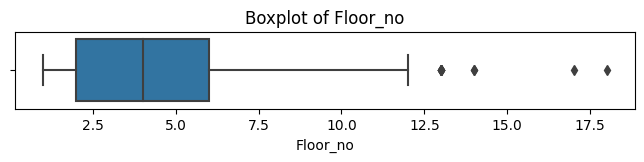

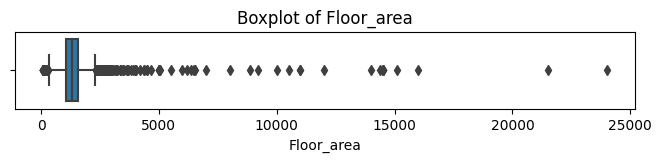

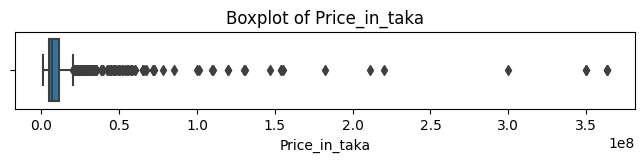

In [59]:
numeric_cols = df.select_dtypes(include='number')
for col in numeric_cols.columns:
    plt.figure(figsize=(8, 1))
    sns.boxplot(x=numeric_cols[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [60]:
# Remove some rows based on criteria (Bedrooms > 10 or Bathrooms > 4)

df = df[(df['Bedrooms'] < 10) & (df['Bathrooms'] < 4)]


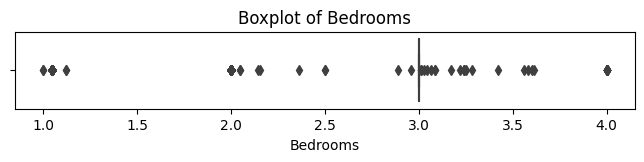

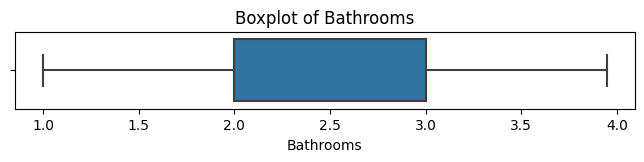

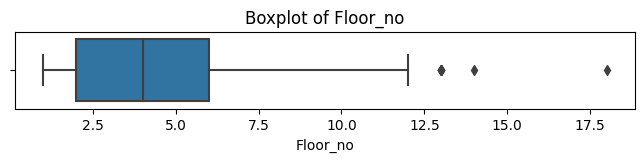

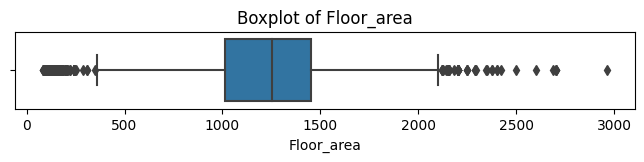

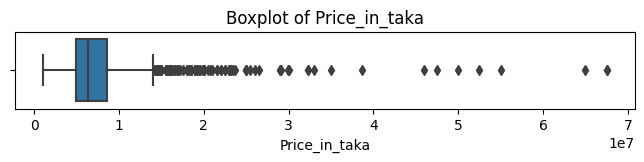

In [61]:
# Let's recheck.

numeric_cols = df.select_dtypes(include='number')
for col in numeric_cols.columns:
    plt.figure(figsize=(8, 1))
    sns.boxplot(x=numeric_cols[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

## 3.4. **Explore Categorical Columns**

In [62]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols

['Title', 'Occupancy_status', 'City', 'Location']

In [63]:
df['Title'].value_counts()

Title
Buy This 240 Sq Ft Shop At Bakalia                                                              2
1445 Sq Ft Residential Apartment Is Available For Sale In Chotora, Cumilla                      2
Valuable 1705 Square Feet Apartment Is Ready To Sale In Kalabagan                               1
Great Location! Check Out This Flat For Sale In 16 No. Chawk Bazaar Ward Which Is 1324 Sq Ft    1
1650 SQ FT flat is now for sale in Khulshi, Khulshi Green Housing Society                       1
                                                                                               ..
Evaluate This 650 Square Feet Apartment For Sale In Mirpur                                      1
An Amazing 1542 Sq.ft -3 Bedroom Apartment Is Up For Sale In Shah Ali Bag .                     1
In Mirpur this flat is up for sale which is 930 SQ FT                                           1
750 Sq Ft Apartment Is Available For Sale At Section 11, Mirpur                                 1
1240 Sq Ft Fla

In [64]:
df['Occupancy_status'].value_counts()

Occupancy_status
vacant      2005
occupied       2
Name: count, dtype: int64

Let's see its impact on price

<Axes: xlabel='Occupancy_status', ylabel='Price_in_taka'>

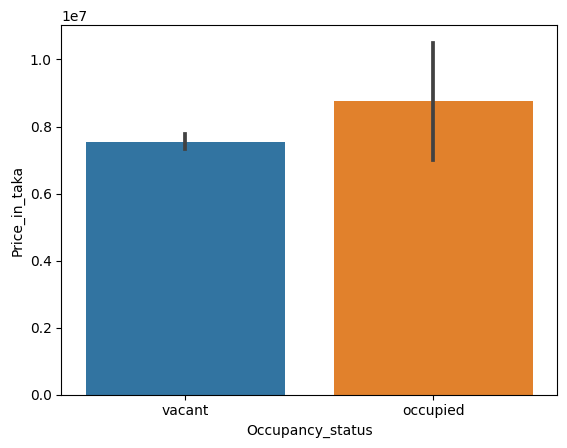

In [65]:
sns.barplot(df,x='Occupancy_status',y='Price_in_taka')

In [66]:
df['City'].value_counts()

City
chattogram          902
dhaka               832
gazipur             139
cumilla             129
narayanganj-city      5
Name: count, dtype: int64

Let's see its impact on price as well.

<Axes: xlabel='City', ylabel='Price_in_taka'>

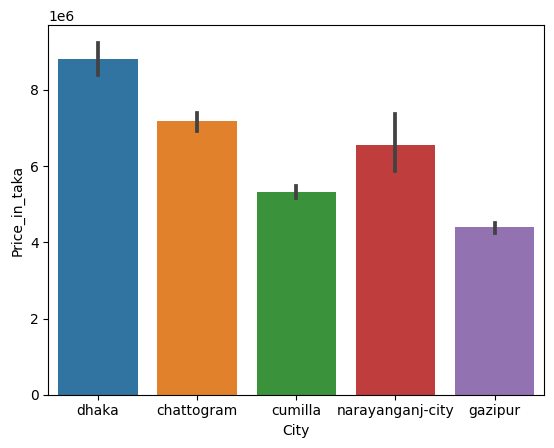

In [67]:
sns.barplot(df,x='City',y='Price_in_taka')

In [68]:
df['Location'].value_counts()

Location
Dewan Bazar, Bakalia                            73
Joydebpur, Gazipur Sadar Upazila                63
Dhaka Trunk Road, 9 No. North Pahartali Ward    57
Tongi, Gazipur Sadar Upazila                    42
North Bagichagaon, Bagichagaon                  35
                                                ..
Malibag College Road, Malibagh                   1
Amtola, Khilkhet                                 1
Ali And Nur Real Estate, Mohammadpur             1
Halishahar Road, Halishahar                      1
Chowrasta, Chandra                               1
Name: count, Length: 406, dtype: int64

## **3.5. Feature Engineering**

### 3.5.1. Remove unnecessary columns

We will remove these columns:
1. Floor_no due to weak correlation with price
2. Title column as it's not needed for prediciton
3. Occupancy_status because highly imbalanced data
4. Location as it has 406 unique values

In [69]:
df.drop(['Floor_no','Title','Occupancy_status','Location'],axis=1, inplace=True)

### 3.5.2. Encode city column

In [70]:
df = pd.get_dummies(df, columns=['City'])

### 3.5.3. Scale features

In [71]:
from sklearn.preprocessing import StandardScaler
# Select numeric columns
numeric_cols = df.select_dtypes(include='number')

# Scale the numeric columns
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)


# **4. Model Building**

In [72]:
# Splitting Training and Testing Data
X = df.drop('Price_in_taka', axis=1)
y = df['Price_in_taka']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


models = {
   'Linear Regression': LinearRegression(),
   'Decision Tree': DecisionTreeRegressor(),
   'K-Nearest Neighbors': KNeighborsRegressor(),
   'Support Vector Regressor': SVR(),
   'Random Forest': RandomForestRegressor(),
   'Gradient Boosting': GradientBoostingRegressor(),
   'AdaBoost': AdaBoostRegressor(),
   'Ridge Regression': Ridge()
}


model_r2 = {}


for name, model in models.items():
   model.fit(X_train, y_train)
   y_pred = model.predict(X_test)
   mse = r2_score(y_test, y_pred)
   model_r2[name] = mse


sorted_errors = sorted(model_r2.items(), key=lambda x: x[1],reverse=True)


# Print model errors
print("Model R-squared:\n-------------")
for name, mse in sorted_errors:
   print(f"{name}: {mse:.2f}")

Model R-squared:
-------------
Random Forest: 0.75
Gradient Boosting: 0.74
K-Nearest Neighbors: 0.71
Decision Tree: 0.68
Support Vector Regressor: 0.61
Ridge Regression: 0.49
Linear Regression: 0.49
AdaBoost: 0.18


If you liked my analysis, please upvote. Thanks! 😊